In [1]:
# ============================================================
# Imports
# ============================================================
import sys
import numpy as np
import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader
from collections import deque
import matplotlib.pyplot as plt

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import DarcyDataset
from neuralop.utils import count_model_params

In [2]:
# ============================================================
# Helper Functions
# ============================================================

def threshold_field(x, tau=-1, boundary=0.0):
    """
    Maps a real-valued field to a binary-valued coefficient field taking
    values in {3, 12}, as used in the Darcy flow normalisation.

    When tau=-1, applies a hard threshold at `boundary`.
    Otherwise, applies a smooth sigmoid-like approximation via tanh,
    parametrised by tau (higher tau = sharper transition).
    """
    if isinstance(x, np.ndarray):
        if tau == -1:
            return np.where(x < boundary, 3.0, 12.0)
        return 0.5 * np.tanh(tau * x) + 0.5
    else:
        if tau == -1:
            return torch.where(x < boundary,
                               torch.tensor(3.0),
                               torch.tensor(12.0))
        return 0.5 * torch.tanh(tau * x) + 0.5


def sample_gaussian_process(N=64, M=256):
    """
    Samples a Gaussian process on an N x N grid using a spectral
    (Karhunen-Loeve) expansion on a finer M x M grid, then subsamples.

    The covariance operator is the inverse of (−Δ + 9I)², which produces
    smooth, spatially correlated samples suitable as diffusion coefficients.

    Parameters
    ----------
    N : int
        Output grid resolution (coarse).
    M : int
        Internal fine grid resolution used for spectral sampling.

    Returns
    -------
    u_coarse : np.ndarray of shape (N, N)
    """
    h_fine = 1.0 / M
    kx = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    ky = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    eigenvalues = KX**2 + KY**2 + 9.0
    covariance_spectrum = 1.0 / eigenvalues**2

    noise = np.random.randn(M, M) + 1j * np.random.randn(M, M)
    u_hat = np.sqrt(covariance_spectrum) * noise
    u_fine = np.fft.ifft2(u_hat).real * M**2

    step = M // N
    u_coarse = u_fine[::step, ::step]
    return u_coarse

In [3]:
# ============================================================
# Data Loading
# ============================================================

def get_data(
    n_train=1_000,
    n_tests=[100, 50],
    train_resolution=64,
    test_resolutions=[64, 128],
    batch_size=32,
    test_batch_sizes=[32, 32],
):
    """
    Loads the Darcy flow dataset, renormalises coefficients to {3, 12},
    and returns data loaders and the data processor.

    Returns
    -------
    train_loader    : DataLoader
    test_loaders    : dict[int, DataLoader]
    data_processor  : DataProcessor
    dataset         : DarcyDataset
    """
    dataset = DarcyDataset(
        root_dir="./darcy_data",
        n_train=n_train,
        n_tests=n_tests,
        train_resolution=train_resolution,
        batch_size=batch_size,
        test_resolutions=test_resolutions,
        test_batch_sizes=test_batch_sizes,
    )

    # Renormalise coefficient fields from {0, 1} to {3, 12}
    for test_set in dataset.test_dbs.values():
        test_set.x = threshold_field(test_set.x, tau=-1, boundary=0.5)
    dataset._train_db.x = threshold_field(dataset._train_db.x, tau=-1, boundary=0.5)

    train_loader = DataLoader(
        dataset.train_db,
        batch_size=batch_size,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

    test_loaders = {
        res: DataLoader(
            dataset.test_dbs[res],
            batch_size=test_bsize,
            shuffle=False,
            num_workers=1,
            pin_memory=True,
            persistent_workers=False,
        )
        for res, test_bsize in zip(test_resolutions, test_batch_sizes)
    }

    return train_loader, test_loaders, dataset.data_processor, dataset

In [4]:
# ============================================================
# FNO Training
# ============================================================

def train_FNO(
    train_loader,
    data_processor,
    device,
    n_modes=(25, 25),
    hidden_channels=32,
    n_layers=4,
    factorization="tucker",
    nonlinearity=F.gelu,
    n_epochs=150,
    save_dir="./checkpoints",
):
    """
    Instantiates and trains an FNO on the Darcy flow operator.

    Returns
    -------
    model : trained FNO
    """
    model = FNO(
        n_modes=n_modes,
        in_channels=1,
        out_channels=1,
        hidden_channels=hidden_channels,
        n_layers=n_layers,
        factorization=factorization,
        non_linearity=nonlinearity,
    ).to(device)

    print(f"\nFNO parameter count: {count_model_params(model):,}")
    sys.stdout.flush()

    optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    h1loss = H1Loss(d=2)
    l2loss = LpLoss(d=2, p=2)

    # Register safe globals for serialisation
    torch.serialization.add_safe_globals([torch._C._nn.gelu])
    torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])

    trainer = Trainer(
        model=model,
        n_epochs=n_epochs,
        device=device,
        data_processor=data_processor,
        wandb_log=False,
        eval_interval=5,
        use_distributed=False,
    )

    trainer.train(
        train_loader=train_loader,
        test_loaders={},
        optimizer=optimizer,
        scheduler=scheduler,
        regularizer=False,
        training_loss=h1loss,
        eval_losses={"h1": h1loss, "l2": l2loss},
        save_every=5,
        save_dir=save_dir,
    )

    return model

In [24]:
def run_MCMC(
    model,
    data_processor,
    true_observations,
    device,
    delta=0.00025,
    n_iterations=40_000,
    tau=-1,
    subsample_ratio=1,
    target_acceptance=0.234,
    adapt_interval=500,
    adapt_cutoff=30_000,
    delta_min=1e-6,
    delta_max=0.49,
    seed=None,
):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    H, W = true_observations.shape[-2], true_observations.shape[-1]
    assert H == W, "Observation grid must be square."
    N = H

    # ------------------------------------------------------------------
    # Pre-fetch normalisers once — avoids a .to(device) call every
    # likelihood evaluation
    # ------------------------------------------------------------------
    out_mean = data_processor.out_normalizer.mean.to(device)
    out_std  = data_processor.out_normalizer.std.to(device)

    true_observations_full   = true_observations.to(device)
    true_observations_sparse = true_observations_full[:, :, ::subsample_ratio, ::subsample_ratio]

    sigma   = true_observations.std().item()
    sigma_sq = sigma ** 2

    # ------------------------------------------------------------------
    # Pre-allocate a reusable input buffer on the GPU — avoids
    # allocating a new tensor and transferring from CPU every iteration
    # ------------------------------------------------------------------
    input_buffer = torch.empty(1, 1, N, N, dtype=torch.float32, device=device)

    def log_likelihood(theta_np):
        """
        Evaluates the Gaussian log-likelihood given a numpy coefficient
        field, using the pre-allocated GPU buffer to avoid repeated
        allocation and host-device transfers.
        """
        input_buffer.copy_(torch.from_numpy(theta_np))
        with torch.no_grad():
            u_pred = model(input_buffer) * out_std + out_mean
        u_pred_sparse = u_pred[:, :, ::subsample_ratio, ::subsample_ratio]
        # Keep as tensor to avoid GPU->CPU sync until accept/reject step
        ll = -0.5 * torch.sum((true_observations_sparse - u_pred_sparse[0, 0]) ** 2) / sigma_sq
        return ll

    # ------------------------------------------------------------------
    # Initialise chain
    # ------------------------------------------------------------------
    u_current     = sample_gaussian_process(N=N)
    theta_current = threshold_field(u_current, tau=tau)
    ll_current    = log_likelihood(theta_current).item()

    theta_evolution   = []
    loss_evolution    = []
    accepted          = []
    nll_window        = deque(maxlen=200)
    n_accepted_window = 0
    adapting          = True

    # ------------------------------------------------------------------
    # pCN sampling loop
    # ------------------------------------------------------------------
    for i in range(n_iterations):

        # --- pCN proposal ---
        u_proposal     = np.sqrt(1 - 2 * delta) * u_current + np.sqrt(2 * delta) * sample_gaussian_process(N=N)
        theta_proposal = threshold_field(u_proposal, tau=tau)

        # --- Accept / reject ---
        ll_proposal  = log_likelihood(theta_proposal)
        log_ratio    = ll_proposal.item() - ll_current  # single GPU->CPU sync per iteration

        if np.log(np.random.rand()) < log_ratio:        # avoids redundant min(1, exp(...))
            u_current     = u_proposal
            theta_current = theta_proposal
            ll_current    = log_ratio + ll_current
            accepted.append(1)
            n_accepted_window += 1
        else:
            accepted.append(0)

        theta_evolution.append(theta_current)
        loss_evolution.append(ll_current)
        nll_window.append(-ll_current)

        # --- Periodic diagnostics and delta adaptation ---
        if (i + 1) % adapt_interval == 0:
            acceptance_rate   = n_accepted_window / adapt_interval
            n_accepted_window = 0

            if adapting:
                factor = np.exp(acceptance_rate - target_acceptance)
                delta  = float(np.clip(delta * factor, delta_min, delta_max))

                if (i + 1) >= adapt_cutoff:
                    adapting = False
                    print(f">>> Adaptation frozen at delta = {delta:.6f}")

            print(f"Iteration {i+1:>6}/{n_iterations} | "
                  f"Acceptance rate: {acceptance_rate:.3f} | "
                  f"Delta: {delta:.6f} | "
                  f"Adapting: {adapting} | "
                  f"Avg NLL (last 200): {np.mean(nll_window):.3f} | "
                  f"Subsampling: 1/{subsample_ratio**2} "
                  f"({true_observations_sparse.numel()} obs points)")

    return {
        "theta_evolution": theta_evolution,
        "loss_evolution":  loss_evolution,
        "accepted":        accepted,
        "best_theta":      theta_current,
        "best_u":          u_current,
        "sigma":           sigma,
        "delta_final":     delta,
    }

In [ ]:
# ============================================================
# Main Pipeline
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loaders, data_processor, dataset = get_data()

true_field        = dataset.test_dbs[64].x[0, 0].unsqueeze(0).unsqueeze(0)
true_observations = dataset.test_dbs[64].y[0, 0].unsqueeze(0).unsqueeze(0)

model = train_FNO(train_loader, data_processor, device)
model = model.to(device)


Using device: cuda
Loading test db for resolution 64 with 100 samples 
Loading test db for resolution 128 with 50 samples 

FNO parameter count: 2,698,289


/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/torch/nn/modules/module.py:1790: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)
/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


Iteration    500/10000 | Acceptance rate: 0.576 | Delta: 0.000352 | Adapting: True | Avg NLL (last 200): 80.284 | Subsampling: 1/16 (256 obs points)
Iteration   1000/10000 | Acceptance rate: 0.416 | Delta: 0.000422 | Adapting: True | Avg NLL (last 200): 19.002 | Subsampling: 1/16 (256 obs points)
Iteration   1500/10000 | Acceptance rate: 0.468 | Delta: 0.000534 | Adapting: True | Avg NLL (last 200): 17.998 | Subsampling: 1/16 (256 obs points)
Iteration   2000/10000 | Acceptance rate: 0.300 | Delta: 0.000570 | Adapting: True | Avg NLL (last 200): 14.086 | Subsampling: 1/16 (256 obs points)
Iteration   2500/10000 | Acceptance rate: 0.388 | Delta: 0.000665 | Adapting: True | Avg NLL (last 200): 11.730 | Subsampling: 1/16 (256 obs points)
Iteration   3000/10000 | Acceptance rate: 0.430 | Delta: 0.000809 | Adapting: True | Avg NLL (last 200): 11.834 | Subsampling: 1/16 (256 obs points)
Iteration   3500/10000 | Acceptance rate: 0.554 | Delta: 0.001114 | Adapting: True | Avg NLL (last 200): 8

In [11]:
# Example: subsample_ratio=4 retains every 4th point → 16x16 effective observations from 64x64
result = run_MCMC(model, data_processor, true_observations, device,
                  n_iterations=10_000, subsample_ratio=4, seed=42)



Iteration    500/10000 | Acceptance rate: 0.576 | Delta: 0.000352 | Adapting: True | Avg NLL (last 200): 80.284 | Subsampling: 1/16 (256 obs points)
Iteration   1000/10000 | Acceptance rate: 0.416 | Delta: 0.000422 | Adapting: True | Avg NLL (last 200): 19.002 | Subsampling: 1/16 (256 obs points)
Iteration   1500/10000 | Acceptance rate: 0.468 | Delta: 0.000534 | Adapting: True | Avg NLL (last 200): 17.998 | Subsampling: 1/16 (256 obs points)
Iteration   2000/10000 | Acceptance rate: 0.300 | Delta: 0.000570 | Adapting: True | Avg NLL (last 200): 14.086 | Subsampling: 1/16 (256 obs points)
Iteration   2500/10000 | Acceptance rate: 0.388 | Delta: 0.000665 | Adapting: True | Avg NLL (last 200): 11.730 | Subsampling: 1/16 (256 obs points)
Iteration   3000/10000 | Acceptance rate: 0.430 | Delta: 0.000809 | Adapting: True | Avg NLL (last 200): 11.834 | Subsampling: 1/16 (256 obs points)
Iteration   3500/10000 | Acceptance rate: 0.554 | Delta: 0.001114 | Adapting: True | Avg NLL (last 200): 8

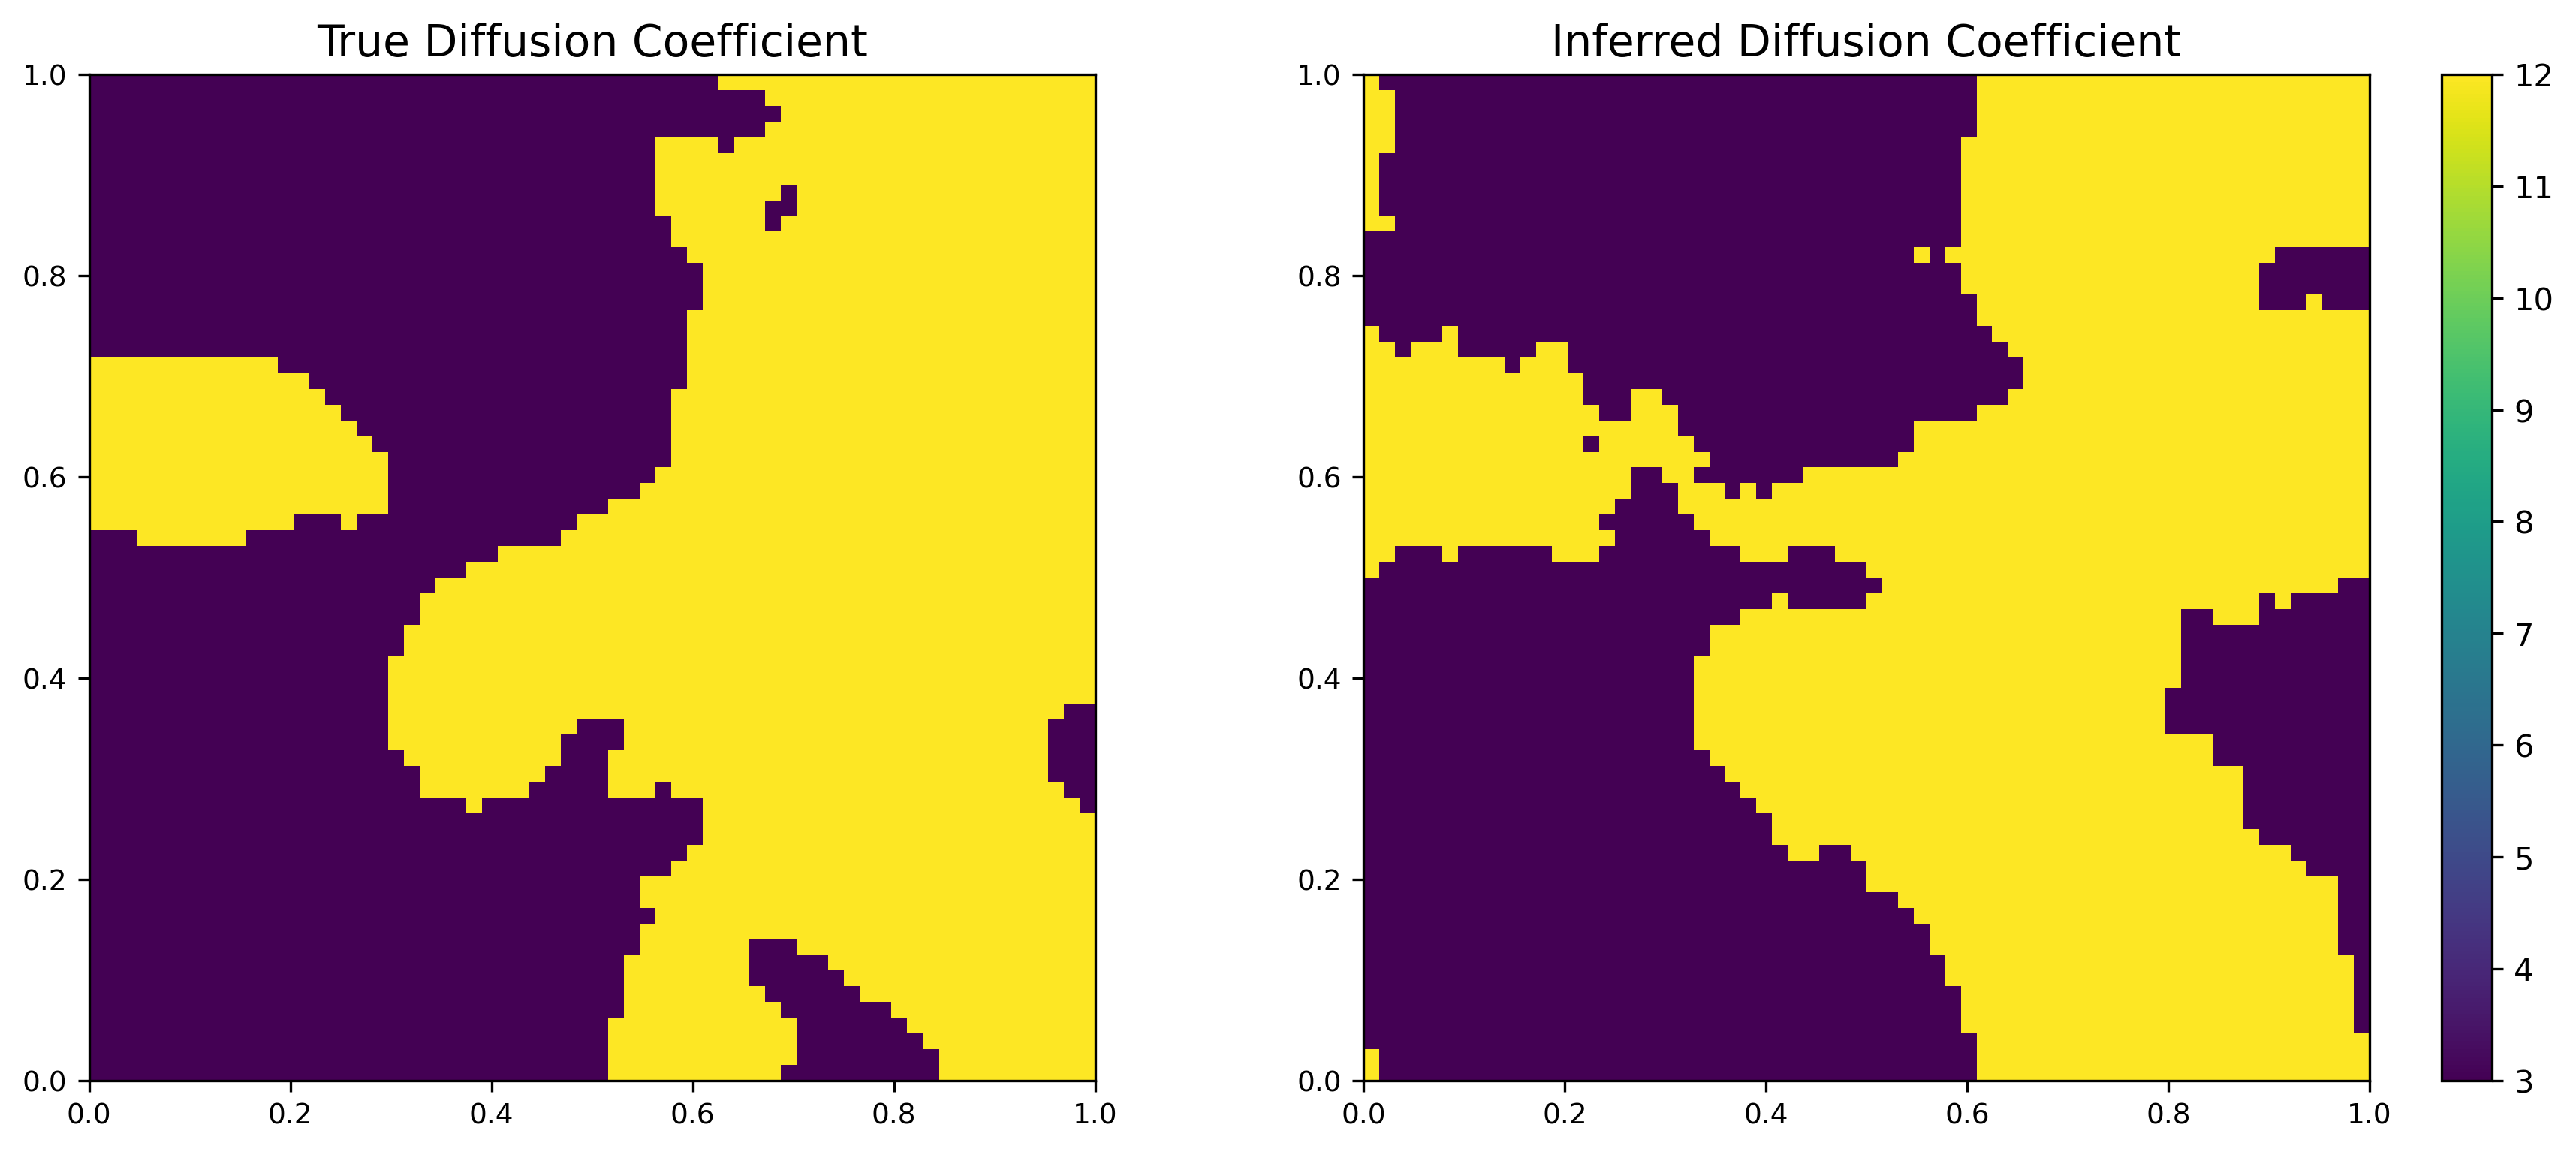

In [12]:
fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300, constrained_layout=True)
fields1 = [
    true_field.cpu().numpy()[0, 0],
    result["best_theta"],
]
titles1 = [
    "True Diffusion Coefficient",
    "Inferred Diffusion Coefficient",
]
for ax, field, title in zip(axs1, fields1, titles1):
    im = ax.imshow(field, extent=[0, 1, 0, 1], origin='lower')
    ax.set_title(title, fontsize=14, loc='center', pad=6)
    ax.tick_params(labelsize=9)

fig1.colorbar(im, ax=axs1, fraction=0.03, pad=0.02, shrink=1.0, aspect=20)
# plt.savefig('figures_for_report/single_true_vs_inferred_coefficients.png', bbox_inches='tight', dpi=300)
plt.show()

In [20]:
# ============================================================
# Ablation Study: H1 Loss vs Subsampling Ratio
# ============================================================

h1loss = H1Loss(d=2)
l2loss = LpLoss(d=2, p=2)

subsample_ratios = [1, 2, 4, 8, 16]

# True coefficient tensor for baseline FNO prediction
theta_true_tensor = true_field.to(device)

# Baseline: FNO prediction under the true coefficient
with torch.no_grad():
    fno_true_pred = model(theta_true_tensor).cpu()[0, 0]

fno_true_norm = (fno_true_pred - fno_true_pred.min()) / (fno_true_pred.max() - fno_true_pred.min())
fno_true_norm = fno_true_norm.unsqueeze(0).unsqueeze(0)
h1_baseline   = h1loss(fno_true_norm, true_observations.cpu()).item()
l2_baseline   = l2loss(fno_true_norm, true_observations.cpu()).item()

print(f"Baseline H1 loss (true coefficient): {h1_baseline:.4f}\n")
print(f"Baseline L2 loss (true coefficient): {l2_baseline:.4f}\n")

Baseline H1 loss (true coefficient): 0.0951

Baseline L2 loss (true coefficient): 0.0819



In [25]:
# ------------------------------------------------------------------
# Run MCMC for each subsampling ratio and record H1 loss
# ------------------------------------------------------------------
h1_losses = {}
l2_losses = {}

for ratio in subsample_ratios:
    print(f"{'='*60}")
    print(f"Running MCMC with subsampling ratio = {ratio} "
          f"({true_observations.shape[-1] // ratio}x{true_observations.shape[-2] // ratio} "
          f"effective observations)")
    print(f"{'='*60}")

    result = run_MCMC(
        model, data_processor, true_observations, device,
        n_iterations=80_000,
        subsample_ratio=ratio,
        seed=42,
    )

    # Posterior mean coefficient
    theta_evolution  = result["theta_evolution"]
    posterior_mean   = np.mean(theta_evolution[-10_000::1_000], axis=0)

    # Reconstruct flow field from posterior mean coefficient
    posterior_mean_tensor = (
        torch.tensor(posterior_mean, dtype=torch.float32)
        .unsqueeze(0).unsqueeze(0)
        .to(device)
    )
    with torch.no_grad():
        predicted_solution = model(posterior_mean_tensor).cpu().numpy()[0, 0]

    # Normalise and compute H1 loss
    pred = torch.tensor(predicted_solution).unsqueeze(0).unsqueeze(0)
    pred_norm = (pred - pred.min()) / (pred.max() - pred.min())
    h1 = h1loss(pred_norm, true_observations.cpu()).item()
    l2 = l2loss(pred_norm, true_observations.cpu()).item()

    h1_losses[ratio] = h1
    l2_losses[ratio] = l2
    print(f"H1 loss at subsampling ratio {ratio}: {h1:.4f}")
    print(f"L2 loss at subsampling ratio {ratio}: {l2:.4f}\n")

Running MCMC with subsampling ratio = 1 (64x64 effective observations)
Iteration    500/80000 | Acceptance rate: 0.278 | Delta: 0.000261 | Adapting: True | Avg NLL (last 200): 1085.959 | Subsampling: 1/1 (4096 obs points)
Iteration   1000/80000 | Acceptance rate: 0.142 | Delta: 0.000238 | Adapting: True | Avg NLL (last 200): 303.552 | Subsampling: 1/1 (4096 obs points)
Iteration   1500/80000 | Acceptance rate: 0.034 | Delta: 0.000195 | Adapting: True | Avg NLL (last 200): 262.353 | Subsampling: 1/1 (4096 obs points)
Iteration   2000/80000 | Acceptance rate: 0.080 | Delta: 0.000167 | Adapting: True | Avg NLL (last 200): 242.267 | Subsampling: 1/1 (4096 obs points)
Iteration   2500/80000 | Acceptance rate: 0.130 | Delta: 0.000151 | Adapting: True | Avg NLL (last 200): 127.205 | Subsampling: 1/1 (4096 obs points)
Iteration   3000/80000 | Acceptance rate: 0.124 | Delta: 0.000135 | Adapting: True | Avg NLL (last 200): 87.977 | Subsampling: 1/1 (4096 obs points)
Iteration   3500/80000 | Acce

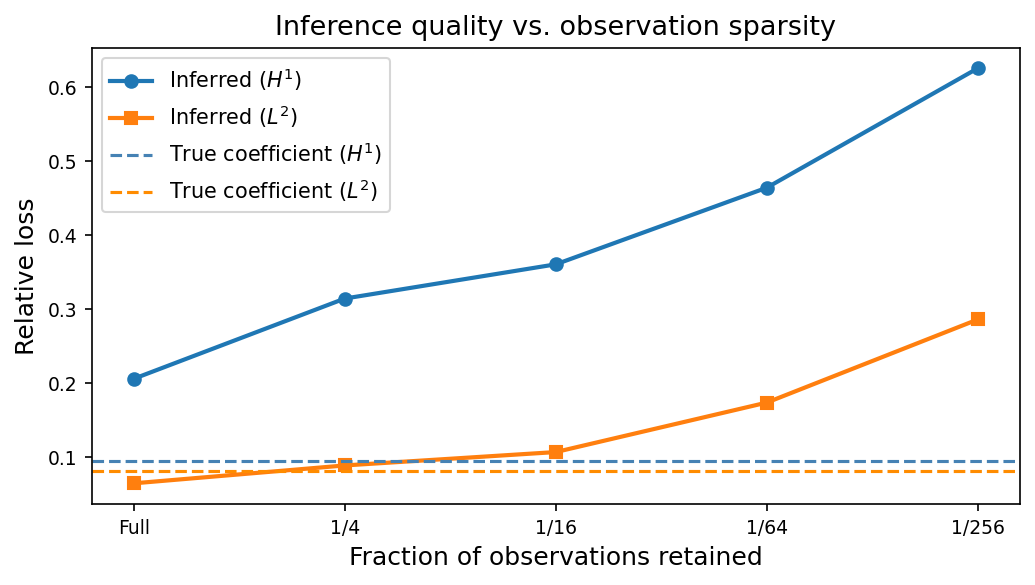


Summary
Ratio      Obs points      H1 Loss      L2 Loss     
-------------------------------------------------
Full       4096            0.2061         0.0648
1/4        1024            0.3145         0.0890
1/16       256             0.3607         0.1071
1/64       64              0.4643         0.1739
1/256      16              0.6257         0.2862

Baseline (true coeff): H1 = 0.0951 | L2 = 0.0819


In [28]:
# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
ratios    = list(h1_losses.keys())
h1_values = list(h1_losses.values())
l2_values = list(l2_losses.values())
x         = np.arange(len(ratios))
xlabels   = ["Full" if r == 1 else f"1/{r**2}" for r in ratios]

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

ax.plot(x, h1_values, marker='o', linewidth=2, label='Inferred ($H^1$)')
ax.plot(x, l2_values, marker='s', linewidth=2, label='Inferred ($L^2$)')
ax.axhline(h1_baseline, color='steelblue', linestyle='--', linewidth=1.5, label='True coefficient ($H^1$)')
ax.axhline(l2_baseline, color='darkorange', linestyle='--', linewidth=1.5, label='True coefficient ($L^2$)')

ax.set_xlabel("Fraction of observations retained", fontsize=12)
ax.set_ylabel("Relative loss", fontsize=12)
ax.set_title("Inference quality vs. observation sparsity", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(fontsize=10)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("figures_for_report/ablation_subsampling_h1_l2.png", bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
print("\nSummary")
print(f"{'Ratio':<10} {'Obs points':<15} {'H1 Loss':<12} {'L2 Loss':<12}")
print("-" * 49)
for r in ratios:
    n_obs = (true_observations.shape[-1] // r) ** 2
    print(f"{'Full' if r == 1 else f'1/{r**2}':<10} {n_obs:<15} {h1_losses[r]:.4f}{'':<8} {l2_losses[r]:.4f}")
print(f"\nBaseline (true coeff): H1 = {h1_baseline:.4f} | L2 = {l2_baseline:.4f}")

In [ ]:
# ============================================================
# Ablation Study: H1 & L2 Loss vs Subsampling Ratio
# Averaged over multiple inference problems
# ============================================================

h1loss = H1Loss(d=2)
l2loss = LpLoss(d=2, p=2)

subsample_ratios = [1, 2, 4, 8, 16]
n_samples        = 5



In [33]:
# ------------------------------------------------------------------
# Baselines: averaged over the same n_samples test problems
# ------------------------------------------------------------------
h1_baselines = []
l2_baselines = []

for i in range(n_samples):
    true_field_i        = dataset.test_dbs[64].x[i].unsqueeze(0)
    true_observations_i = dataset.test_dbs[64].y[i].unsqueeze(0)

    with torch.no_grad():
        fno_true_pred = model(true_field_i.to(device)).cpu()[0, 0]

    # Normalise both prediction and target consistently
    fno_norm  = (fno_true_pred - fno_true_pred.min()) / (fno_true_pred.max() - fno_true_pred.min())
    fno_norm  = fno_norm.unsqueeze(0).unsqueeze(0)

    obs        = true_observations_i.cpu()[0, 0]
    obs_norm   = (obs - obs.min()) / (obs.max() - obs.min())
    obs_norm   = obs_norm.unsqueeze(0).unsqueeze(0)

    h1_baselines.append(h1loss(fno_norm, obs_norm).item())
    l2_baselines.append(l2loss(fno_norm, obs_norm).item())

h1_baseline_mean = np.mean(h1_baselines)
h1_baseline_std  = np.std(h1_baselines)
l2_baseline_mean = np.mean(l2_baselines)
l2_baseline_std  = np.std(l2_baselines)

print(f"Baseline H1 (true coeff): {h1_baseline_mean:.4f} ± {h1_baseline_std:.4f}")
print(f"Baseline L2 (true coeff): {l2_baseline_mean:.4f} ± {l2_baseline_std:.4f}\n")

Baseline H1 (true coeff): 0.0863 ± 0.0305
Baseline L2 (true coeff): 0.0311 ± 0.0140



In [ ]:
# ------------------------------------------------------------------
# Run MCMC for each subsampling ratio, averaged over n_samples
# ------------------------------------------------------------------
# Each dict maps ratio -> list of per-sample losses
h1_losses = {r: [] for r in subsample_ratios}
l2_losses = {r: [] for r in subsample_ratios}

for i in range(n_samples):
    true_field_i        = dataset.test_dbs[64].x[i].unsqueeze(0)
    true_observations_i = dataset.test_dbs[64].y[i].unsqueeze(0)

    for ratio in subsample_ratios:
        print(f"{'='*60}")
        print(f"Sample {i+1}/{n_samples} | Subsampling ratio = {ratio} "
              f"({true_observations_i.shape[-1] // ratio}x"
              f"{true_observations_i.shape[-2] // ratio} effective observations)")
        print(f"{'='*60}")

        result = run_MCMC(
            model, data_processor, true_observations_i, device,
            n_iterations=60_000,
            subsample_ratio=ratio,
            seed=42 + i,   # different seed per sample, reproducible
        )

        # Posterior mean coefficient from thinned post-burn-in chain
        theta_evolution = result["theta_evolution"]
        posterior_mean  = np.mean(theta_evolution[-10_000::1_000], axis=0)

        posterior_mean_tensor = (
            torch.tensor(posterior_mean, dtype=torch.float32)
            .unsqueeze(0).unsqueeze(0)
            .to(device)
        )
        with torch.no_grad():
            predicted_solution = model(posterior_mean_tensor).cpu()[0, 0]

        # Normalise both prediction and target consistently
        pred_norm = (predicted_solution - predicted_solution.min()) / (predicted_solution.max() - predicted_solution.min())
        pred_norm = pred_norm.unsqueeze(0).unsqueeze(0)

        obs        = true_observations_i.cpu()[0, 0]
        obs_norm   = (obs - obs.min()) / (obs.max() - obs.min())
        obs_norm   = obs_norm.unsqueeze(0).unsqueeze(0)

        h1 = h1loss(pred_norm, obs_norm).item()
        l2 = l2loss(pred_norm, obs_norm).item()

        print(f"H1 = {h1:.4f} | L2 = {l2:.4f}\n")

# Aggregate mean and std across samples
h1_means = np.array([np.mean(h1_losses[r]) for r in subsample_ratios])
h1_stds  = np.array([np.std(h1_losses[r])  for r in subsample_ratios])
l2_means = np.array([np.mean(l2_losses[r]) for r in subsample_ratios])
l2_stds  = np.array([np.std(l2_losses[r])  for r in subsample_ratios])

In [ ]:
# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
show_error_bars  = True   # <-- toggle error bars here


x       = np.arange(len(subsample_ratios))
xlabels = ["Full" if r == 1 else f"1/{r**2}" for r in subsample_ratios]

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

eb_kwargs = dict(capsize=4, linewidth=2)

if show_error_bars:
    ax.errorbar(x, h1_means, yerr=h1_stds, marker='o', label='Inferred ($H^1$)', **eb_kwargs)
    ax.errorbar(x, l2_means, yerr=l2_stds, marker='s', label='Inferred ($L^2$)', **eb_kwargs)
else:
    ax.plot(x, h1_means, marker='o', linewidth=2, label='Inferred ($H^1$)')
    ax.plot(x, l2_means, marker='s', linewidth=2, label='Inferred ($L^2$)')

# Baseline bands — shaded ± 1 std, dashed mean line
for mean, std, color, label in [
    (h1_baseline_mean, h1_baseline_std, 'steelblue',  'True coefficient ($H^1$)'),
    (l2_baseline_mean, l2_baseline_std, 'darkorange', 'True coefficient ($L^2$)'),
]:
    ax.axhline(mean, color=color, linestyle='--', linewidth=1.5, label=label)
    if show_error_bars:
        ax.axhspan(mean - std, mean + std, color=color, alpha=0.10)

ax.set_xlabel("Fraction of observations retained", fontsize=12)
ax.set_ylabel("Relative loss", fontsize=12)
ax.set_title("Inference quality vs. observation sparsity", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(fontsize=10)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("figures_for_report/ablation_subsampling_h1_l2.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
print("\nSummary (mean ± std over 10 samples)")
print(f"{'Ratio':<10} {'Obs points':<15} {'H1 Loss':<22} {'L2 Loss':<22}")
print("-" * 69)
for r, h1_m, h1_s, l2_m, l2_s in zip(subsample_ratios, h1_means, h1_stds, l2_means, l2_stds):
    n_obs = (true_observations_i.shape[-1] // r) ** 2
    label = "Full" if r == 1 else f"1/{r**2}"
    print(f"{label:<10} {n_obs:<15} {h1_m:.4f} ± {h1_s:.4f}    {l2_m:.4f} ± {l2_s:.4f}")
print(f"\nBaseline: H1 = {h1_baseline_mean:.4f} ± {h1_baseline_std:.4f} | "
      f"L2 = {l2_baseline_mean:.4f} ± {l2_baseline_std:.4f}")

In [ ]:
# ============================================================
# Ablation Study: H1 & L2 Loss vs Number of Fourier Modes
# Averaged over multiple inference problems
# ============================================================

h1loss = H1Loss(d=2)
l2loss = LpLoss(d=2, p=2)

fourier_modes_list = [1, 6, 12, 18, 24, 30]
n_samples          = 5

# ------------------------------------------------------------------
# Run for each Fourier mode setting
# ------------------------------------------------------------------
h1_losses = {k: [] for k in fourier_modes_list}
l2_losses = {k: [] for k in fourier_modes_list}

for k_max in fourier_modes_list:
    print(f"{'='*60}")
    print(f"Training FNO with Fourier modes = ({k_max}, {k_max})")
    print(f"{'='*60}")

    # Train a fresh FNO with this mode count
    model_k = train_FNO(
        train_loader, data_processor, device,
        n_modes=(k_max, k_max),
    )
    model_k.eval()

    for i in range(n_samples):
        true_field_i        = dataset.test_dbs[64].x[i].unsqueeze(0)
        true_observations_i = dataset.test_dbs[64].y[i].unsqueeze(0)

        result = run_MCMC(
            model_k, data_processor, true_observations_i, device,
            n_iterations=40_000,
            adapt_cutoff=20_000,
            subsample_ratio=1,
            seed=42 + i,
        )

        # Posterior mean coefficient from thinned post-burn-in chain
        theta_evolution = result["theta_evolution"]
        posterior_mean  = np.mean(theta_evolution[-10_000::1_000], axis=0)

        posterior_mean_tensor = (
            torch.tensor(posterior_mean, dtype=torch.float32)
            .unsqueeze(0).unsqueeze(0)
            .to(device)
        )
        with torch.no_grad():
            predicted_solution = model_k(posterior_mean_tensor).cpu()[0, 0]

        # Normalise both prediction and target consistently
        pred_norm = (predicted_solution - predicted_solution.min()) / (predicted_solution.max() - predicted_solution.min())
        pred_norm = pred_norm.unsqueeze(0).unsqueeze(0)

        obs      = true_observations_i.cpu()[0, 0]
        obs_norm = (obs - obs.min()) / (obs.max() - obs.min())
        obs_norm = obs_norm.unsqueeze(0).unsqueeze(0)

        h1 = h1loss(pred_norm, obs_norm).item()
        l2 = l2loss(pred_norm, obs_norm).item()

        h1_losses[k_max].append(h1)
        l2_losses[k_max].append(l2)

        print(f"  Sample {i+1}/{n_samples} | H1 = {h1:.4f} | L2 = {l2:.4f}")

    print(f"  Mean H1 = {np.mean(h1_losses[k_max]):.4f} ± {np.std(h1_losses[k_max]):.4f}")
    print(f"  Mean L2 = {np.mean(l2_losses[k_max]):.4f} ± {np.std(l2_losses[k_max]):.4f}\n")

# ------------------------------------------------------------------
# Baseline: default model (k_max=25) with true coefficient
# ------------------------------------------------------------------
h1_baselines = []
l2_baselines = []

for i in range(n_samples):
    true_field_i        = dataset.test_dbs[64].x[i].unsqueeze(0)
    true_observations_i = dataset.test_dbs[64].y[i].unsqueeze(0)

    with torch.no_grad():
        fno_true_pred = model(true_field_i.to(device)).cpu()[0, 0]

    fno_norm = (fno_true_pred - fno_true_pred.min()) / (fno_true_pred.max() - fno_true_pred.min())
    fno_norm = fno_norm.unsqueeze(0).unsqueeze(0)

    obs      = true_observations_i.cpu()[0, 0]
    obs_norm = (obs - obs.min()) / (obs.max() - obs.min())
    obs_norm = obs_norm.unsqueeze(0).unsqueeze(0)

    h1_baselines.append(h1loss(fno_norm, obs_norm).item())
    l2_baselines.append(l2loss(fno_norm, obs_norm).item())

h1_baseline_mean, h1_baseline_std = np.mean(h1_baselines), np.std(h1_baselines)
l2_baseline_mean, l2_baseline_std = np.mean(l2_baselines), np.std(l2_baselines)

print(f"Baseline H1 (true coeff, k_max=25): {h1_baseline_mean:.4f} ± {h1_baseline_std:.4f}")
print(f"Baseline L2 (true coeff, k_max=25): {l2_baseline_mean:.4f} ± {l2_baseline_std:.4f}")

# ------------------------------------------------------------------
# Aggregate
# ------------------------------------------------------------------
h1_means = np.array([np.mean(h1_losses[k]) for k in fourier_modes_list])
h1_stds  = np.array([np.std(h1_losses[k])  for k in fourier_modes_list])
l2_means = np.array([np.mean(l2_losses[k]) for k in fourier_modes_list])
l2_stds  = np.array([np.std(l2_losses[k])  for k in fourier_modes_list])



Training FNO with Fourier modes = (1, 1)

FNO parameter count: 22,649


/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/torch/nn/modules/module.py:1790: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)
/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


Iteration    500/60000 | Acceptance rate: 0.326 | Delta: 0.000274 | Adapting: True | Avg NLL (last 200): 1108.510 | Subsampling: 1/1 (4096 obs points)
Iteration   1000/60000 | Acceptance rate: 0.192 | Delta: 0.000263 | Adapting: True | Avg NLL (last 200): 417.859 | Subsampling: 1/1 (4096 obs points)
Iteration   1500/60000 | Acceptance rate: 0.158 | Delta: 0.000244 | Adapting: True | Avg NLL (last 200): 133.851 | Subsampling: 1/1 (4096 obs points)
Iteration   2000/60000 | Acceptance rate: 0.122 | Delta: 0.000218 | Adapting: True | Avg NLL (last 200): 123.385 | Subsampling: 1/1 (4096 obs points)
Iteration   2500/60000 | Acceptance rate: 0.148 | Delta: 0.000200 | Adapting: True | Avg NLL (last 200): 115.992 | Subsampling: 1/1 (4096 obs points)
Iteration   3000/60000 | Acceptance rate: 0.152 | Delta: 0.000184 | Adapting: True | Avg NLL (last 200): 110.734 | Subsampling: 1/1 (4096 obs points)
Iteration   3500/60000 | Acceptance rate: 0.152 | Delta: 0.000170 | Adapting: True | Avg NLL (last 

KeyboardInterrupt: 

In [ ]:
# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
show_error_bars    = True  # <-- toggle error bars here


x = np.arange(len(fourier_modes_list))

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

eb_kwargs = dict(capsize=4, linewidth=2)

if show_error_bars:
    ax.errorbar(x, h1_means, yerr=h1_stds, marker='o', label='Inferred ($H^1$)', **eb_kwargs)
    ax.errorbar(x, l2_means, yerr=l2_stds, marker='s', label='Inferred ($L^2$)', **eb_kwargs)
else:
    ax.plot(x, h1_means, marker='o', linewidth=2, label='Inferred ($H^1$)')
    ax.plot(x, l2_means, marker='s', linewidth=2, label='Inferred ($L^2$)')

for mean, std, color, label in [
    (h1_baseline_mean, h1_baseline_std, 'steelblue',  'True coefficient ($H^1$)'),
    (l2_baseline_mean, l2_baseline_std, 'darkorange', 'True coefficient ($L^2$)'),
]:
    ax.axhline(mean, color=color, linestyle='--', linewidth=1.5, label=label)
    if show_error_bars:
        ax.axhspan(mean - std, mean + std, color=color, alpha=0.10)

ax.set_xlabel("Number of Fourier modes $k_{\\max}$", fontsize=12)
ax.set_ylabel("Relative loss", fontsize=12)
ax.set_title("Inference quality vs. number of Fourier modes", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in fourier_modes_list])
ax.legend(fontsize=10)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("figures_for_report/ablation_fourier_modes_h1_l2.png", bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
print("\nSummary (mean ± std over 10 samples)")
print(f"{'k_max':<10} {'H1 Loss':<25} {'L2 Loss':<25}")
print("-" * 60)
for k, h1_m, h1_s, l2_m, l2_s in zip(fourier_modes_list, h1_means, h1_stds, l2_means, l2_stds):
    print(f"{k:<10} {h1_m:.4f} ± {h1_s:.4f}         {l2_m:.4f} ± {l2_s:.4f}")
print(f"\nBaseline (true coeff): H1 = {h1_baseline_mean:.4f} ± {h1_baseline_std:.4f} | "
      f"L2 = {l2_baseline_mean:.4f} ± {l2_baseline_std:.4f}")